<a href="https://colab.research.google.com/github/Thilini-Piyumika/Electronic-Health-Record-Quality-Scorecard/blob/main/EHRDataQualityScoreCardFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**EHR Data Quality Scorecard**


Assessing reaserch readiness of Electronic Helth Records using machine learning.

Approach:

Data preprocessing
Multiple algorithm comparison
Model evaluation and selection

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Step 1: Import Libabries

In [47]:
# import libraries
# Data handling and analysis
import pandas as pd
#Perform calculations and support statistics
import numpy as np
# Data visualization
import matplotlib.pyplot as plt
# Advanced statistical visualization

import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

Step 2: Load the dataset

In [4]:
df = pd.read_excel("/content/drive/MyDrive/Final_EHR_DATASET2.xlsx")

Step 3: Create new features by dividing new varraibles.

In [5]:
#Create ratio features

df["obs_per_visit"] = df["number_of_observations"] / (df["number_of_visits"] + 1)
df["med_per_condition"] = df["number_of_medications"] / (df["number_of_conditions"] + 1)
df["proc_per_visit"] = df["number_of_procedures"] / (df["number_of_visits"] + 1)


Step 4: Log transformation to handle zeros carefully

In [6]:
# transform large counts- make more realistic
for col in df.columns[1:]:
    df[col] = np.log1p(df[col])


 Step 4: Create Research Richness Score

In [7]:
df["richness_score"] = (
    df["number_of_visits"] +
    df["number_of_observations"] +
    df["number_of_conditions"] +
    df["number_of_medications"] +
    df["number_of_procedures"]
)


Step 5: Convert Richness Score to Binary Label

In [8]:
#Convert to binary label
threshold = df["richness_score"].quantile(0.6)
df["research_ready"] = (df["richness_score"] > threshold).astype(int)


Step 6: Define Features and Target

In [9]:
#define features and traget'
X = df.drop(["PATIENT Id", "research_ready", "richness_score"], axis=1)
y = df["research_ready"]


Step 7: Split est data and train data

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


Step 8: Build pipeline to data preprocessing and model training combining in a structured way

In [16]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(
        n_estimators=100,
        max_depth=6,
        random_state=42
    ))
])


Step 9: Train the model using training data

In [17]:
pipeline.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 RandomForestClassifier(max_depth=6, random_state=42))])

Step 10: Evaluate on test data

In [18]:
y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.9871420222092344
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1027
           1       0.99      0.98      0.98       684

    accuracy                           0.99      1711
   macro avg       0.99      0.99      0.99      1711
weighted avg       0.99      0.99      0.99      1711



Step 11: Perform Cross-Validation to Check Model Stability

In [21]:
cv_scores = cross_val_score(pipeline, X, y, cv=5)
print("CV Accuracy:", cv_scores.mean())


CV Accuracy: 0.9409130187431769


Step 12: Analyze Cross-Validation Stability

In [22]:
print("All CV Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())


All CV Scores: [0.79579316 0.98947368 0.99298246 0.96140351 0.96491228]
Mean CV Accuracy: 0.9409130187431769
Standard Deviation: 0.07365454713714276


Steps 13: Add Controlled Noise to Richness Score to prevent leraning exact threshold rule other model can do revers engineering easily

In [23]:
# Add noise to richness score
df["richness_score"] += np.random.normal(0, 0.3, len(df))


Step 14: Define Classification Threshold Using Median

In [24]:
threshold = df["richness_score"].quantile(0.5)


Step 15: Remove Highly Influential Feature to Reduce Shortcut Learning

In [25]:
X = X.drop("number_of_visits", axis=1)


Step 16: Control maximum depth for decision tree

In [26]:
max_depth=4


Step 17: Construct Weighted Research-Readiness Score and Generate Binary Label

In [27]:
df["richness_score"] = (
    0.3 * df["number_of_visits"] +
    0.25 * df["number_of_observations"] +
    0.2 * df["number_of_conditions"] +
    0.15 * df["number_of_medications"] +
    0.1 * df["number_of_procedures"]
)

# Add controlled noise
df["richness_score"] += np.random.normal(0, 0.5, len(df))

threshold = df["richness_score"].quantile(0.5)
df["research_ready"] = (df["richness_score"] > threshold).astype(int)


Step 18: Define Features (X) and Target Variable (y)

In [28]:
X = df.drop(["PATIENT Id", "richness_score", "research_ready"], axis=1)
y = df["research_ready"]


Step 19: Again split train and test data

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


Step 20: Define the Random Forest Model Using a Pipeline

In [30]:
rf_pipeline = Pipeline([
    ("model", RandomForestClassifier(
        n_estimators=100,
        max_depth=4,
        random_state=42
    ))
])


Step 21: Again analyse cross validation stability

In [33]:
cv_scores = cross_val_score(rf_pipeline, X, y, cv=5)
print("All CV Scores:", cv_scores)
print("Mean CV:", cv_scores.mean())
print("Std:", cv_scores.std())


All CV Scores: [0.81945662 0.88333333 0.84649123 0.70701754 0.70438596]
Mean CV: 0.7921369374356135
Std: 0.07343443438645815


Step 22: Improve Model Stability by Increasing Number of Trees

In [32]:
RandomForestClassifier(
    n_estimators=300,
    max_depth=4,
    random_state=42
)


RandomForestClassifier(max_depth=4, n_estimators=300, random_state=42)

Step 23: Train the Improved Random Forest Model

In [34]:
rf_pipeline.fit(X_train, y_train)


Pipeline(steps=[('model',
                 RandomForestClassifier(max_depth=4, random_state=42))])

Step 25: Evaluate Tuned Random Forest Model on Test Data

In [35]:
y_pred = rf_pipeline.predict(X_test)

print("Train Accuracy:", rf_pipeline.score(X_train, y_train))
print("Test Accuracy:", rf_pipeline.score(X_test, y_test))
print(classification_report(y_test, y_pred))


Train Accuracy: 0.8428571428571429
Test Accuracy: 0.8141437755698422
              precision    recall  f1-score   support

           0       0.79      0.86      0.82       856
           1       0.85      0.77      0.80       855

    accuracy                           0.81      1711
   macro avg       0.82      0.81      0.81      1711
weighted avg       0.82      0.81      0.81      1711



Step 26: Evaluate confusion matrix

In [36]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))


[[738 118]
 [200 655]]


Step 27: Analyze Feature Importance Using Random Forest

In [37]:
importance = pd.Series(
    rf_pipeline.named_steps["model"].feature_importances_,
    index=X.columns
)
importance.sort_values(ascending=False)


,0
number_of_observations,0.284070
obs_per_visit,0.245999
number_of_medications,0.140897
number_of_conditions,0.088025
number_of_visits,0.086425
number_of_procedures,0.085394
med_per_condition,0.044645
number_of_imaging,0.012339
proc_per_visit,0.006733
number_of_immunizations,0.005031


Step 28: Train and Evaluate Logistic Regression Model

In [38]:
log_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        C=0.5,
        max_iter=2000
    ))
])

log_pipeline.fit(X_train, y_train)

y_pred_log = log_pipeline.predict(X_test)

print("Logistic Train Accuracy:", log_pipeline.score(X_train, y_train))
print("Logistic Test Accuracy:", log_pipeline.score(X_test, y_test))
print(classification_report(y_test, y_pred_log))


Logistic Train Accuracy: 0.8363408521303258
Logistic Test Accuracy: 0.8194038573933372
              precision    recall  f1-score   support

           0       0.79      0.87      0.83       856
           1       0.85      0.77      0.81       855

    accuracy                           0.82      1711
   macro avg       0.82      0.82      0.82      1711
weighted avg       0.82      0.82      0.82      1711



Step 29: Train and Evaluate Decision Tree

In [39]:
tree_pipeline = Pipeline([
    ("model", DecisionTreeClassifier(
        max_depth=4,
        random_state=42
    ))
])

tree_pipeline.fit(X_train, y_train)

y_pred_tree = tree_pipeline.predict(X_test)

print("Tree Train Accuracy:", tree_pipeline.score(X_train, y_train))
print("Tree Test Accuracy:", tree_pipeline.score(X_test, y_test))
print(classification_report(y_test, y_pred_tree))


Tree Train Accuracy: 0.8345864661654135
Tree Test Accuracy: 0.7960257159555816
              precision    recall  f1-score   support

           0       0.79      0.81      0.80       856
           1       0.81      0.78      0.79       855

    accuracy                           0.80      1711
   macro avg       0.80      0.80      0.80      1711
weighted avg       0.80      0.80      0.80      1711



Step 30: Model comparison

In [40]:
print("Logistic CV:", cross_val_score(log_pipeline, X, y, cv=5).mean())
print("Decision Tree CV:", cross_val_score(tree_pipeline, X, y, cv=5).mean())
print("Random Forest CV:", cross_val_score(rf_pipeline, X, y, cv=5).mean())


Logistic CV: 0.8037160385626644
Decision Tree CV: 0.7775778403062873
Random Forest CV: 0.7921369374356135


In [41]:
print("Logistic Train:", log_pipeline.score(X_train, y_train))
print("Logistic Test:", log_pipeline.score(X_test, y_test))


Logistic Train: 0.8363408521303258
Logistic Test: 0.8194038573933372


**Distribution before and after log tranformation**

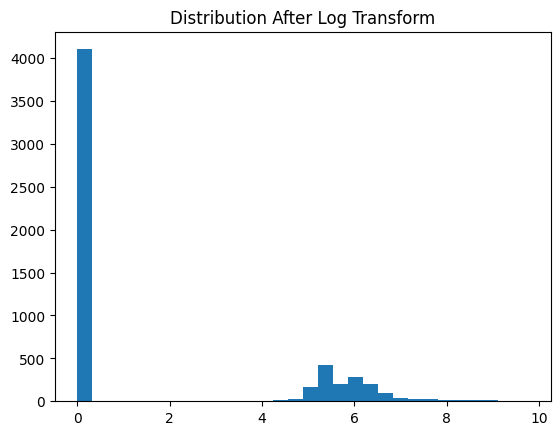

In [42]:
import matplotlib.pyplot as plt

plt.hist(df["number_of_observations"], bins=30)
plt.title("Distribution After Log Transform")
plt.show()


**Richness Score Distribution**

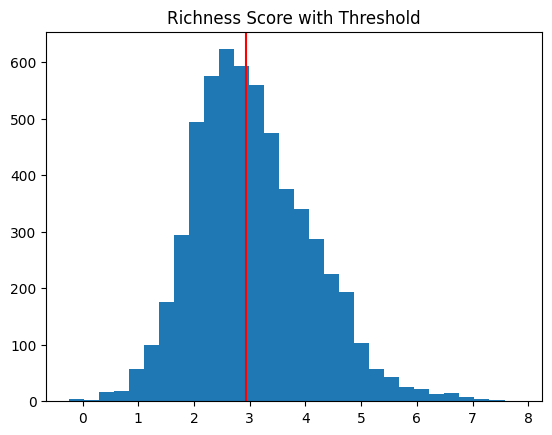

In [43]:
plt.hist(df["richness_score"], bins=30)
plt.axvline(threshold, color='red')
plt.title("Richness Score with Threshold")
plt.show()


**Confusion Matrix Heatmap**

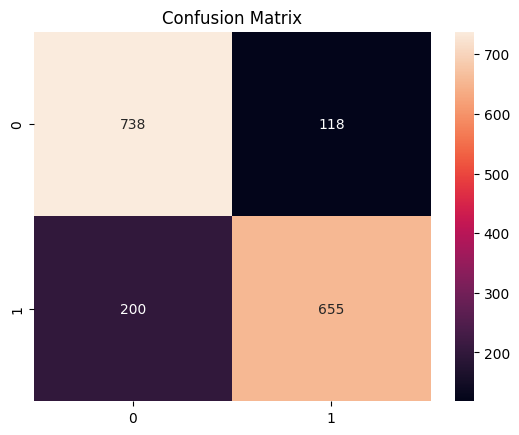

In [44]:
import seaborn as sns

sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()


**Feature Importance Bar Chart**

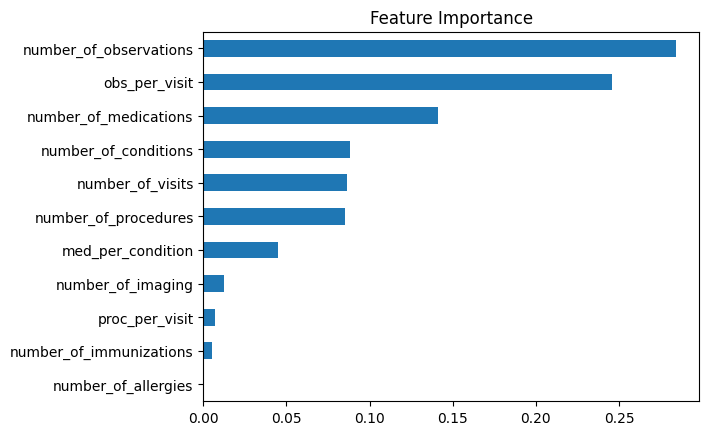

In [45]:
importance.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()


**ROC Curve**

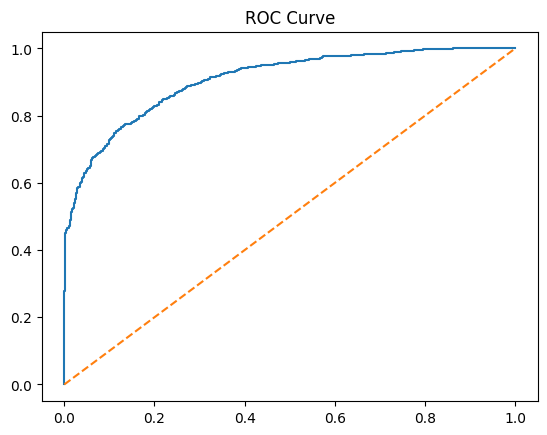

In [46]:
from sklearn.metrics import roc_curve, auc

y_prob = log_pipeline.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.show()


In [48]:
# get predictions for all models

y_pred_log = log_pipeline.predict(X_test)
y_pred_dt = tree_pipeline.predict(X_test)
y_pred_rf = rf_pipeline.predict(X_test)


In [49]:
#compute confusion matrices
cm_log = confusion_matrix(y_test, y_pred_log)
cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_rf = confusion_matrix(y_test, y_pred_rf)


**Plot confusion matrix**

In [50]:
def plot_cm(cm, title):
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


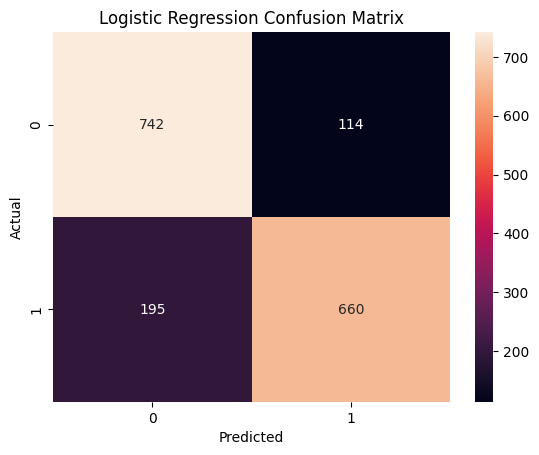

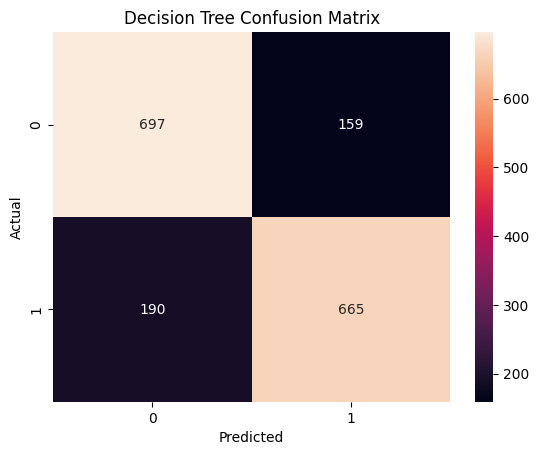

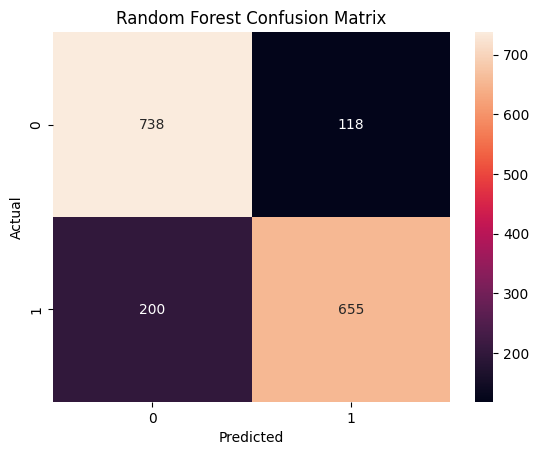

In [51]:
#Plot all thre
plot_cm(cm_log, "Logistic Regression Confusion Matrix")
plot_cm(cm_dt, "Decision Tree Confusion Matrix")
plot_cm(cm_rf, "Random Forest Confusion Matrix")
